# Импорты

In [1]:
import numpy as np
import pandas as pd
import graphblas
import matplotlib.pyplot as plt
import time
from graphblas import Matrix, Vector, Scalar
from graphblas import semiring, monoid, select
from graphblas.io import from_scipy_sparse
from pathlib import Path
from scipy.io import mmread
from scipy.sparse import csr_matrix

# Вспомогательные функции

In [2]:
# Функция для создания объекта матрицы из python-graphblas из numpy массива
def load_graph_from_dense(arr: np.ndarray) -> Matrix:
    return Matrix.from_dense(arr, missing_value=0)

# Функция для проверки неориентированности графа
def check_undirected(A: Matrix) -> bool:
    if not A.isequal(A.T):
        raise ValueError("Граф ориентированный, матрица смежности не симметрична!")
    return True

# Задачи

## Задача 1

In [3]:
def find_num_triangles_through_cubed_matrix(A: Matrix) -> int:
    # Считаем матрицу A^2
    A_squared = A.mxm(A, semiring.plus_times).new()

    # Считаем матрицу A^3
    A_cubed = A_squared.mxm(A, semiring.plus_times).new()

    # Считаем сумму по диагонали матрицы A^3
    A_cubed_trace_sum = A_cubed.diag().reduce(monoid.plus).new().value

    # Учитываем ситуацию, когда на диагонали одни нули
    if A_cubed_trace_sum is None:
        A_cubed_trace_sum = 0

    # Делим на 6 так как нам надо учесть 3 стартовых точки в одном треугольнике
    # и 2 направления движения: делим на 2 * 3 = 6
    num_triangles = A_cubed_trace_sum // 6

    return num_triangles

## Задача 2

In [4]:
def find_num_triangles_through_squared_matrix(A: Matrix) -> int:
    # Считаем матрицу A^2 с маской A.S (только там, где есть ребро между i и j в A^1)
    A_squared = A.mxm(A, semiring.plus_times).new(mask=A.S)

    # Считаем сумму всех элементов
    A_squared_sum_of_all_elements = A_squared.reduce_scalar(monoid.plus).new().value

    # Учитываем ситуацию, когда у нас в матрице одни нули
    if A_squared_sum_of_all_elements is None:
        A_squared_sum_of_all_elements = 0

    # Делим на 6 так как нам надо учесть 3 стартовых точки в одном треугольнике
    # и 2 направления движения: делим на 2 * 3 = 6
    num_triangles = A_squared_sum_of_all_elements // 6

    return num_triangles

### Задача 3

In [5]:
def find_num_triangles_cohen_algorithm(A: Matrix) -> int:
    # Нижнетреугольная матрица
    L = select.tril(A, -1).new()

    # Верхнетреугольная матрица
    U = select.triu(A, 1).new()

    # Считаем матричным умножением L x U с маской A.S (только там, где есть ребро между i и j в A)
    L_dot_U_masked = L.mxm(U, semiring.plus_times).new(mask=A.S)

    # Считаем сумму всех элементов
    L_dot_U_masked_sum_of_all_elements = L_dot_U_masked.reduce_scalar(monoid.plus).new().value

    # Учитываем ситуацию, когда у нас в матрице одни нули
    if L_dot_U_masked_sum_of_all_elements is None:
        L_dot_U_masked_sum_of_all_elements = 0

    # Делим на 2
    num_triangles = L_dot_U_masked_sum_of_all_elements // 2

    return num_triangles

## Задача 4

In [6]:
def find_num_triangles_sandia_algorithm(A: Matrix) -> int:
    # Нижнетреугольная матрица
    L = select.tril(A, -1).new()

    # Считаем L^2 с маской L.S (только там, где есть ребро между i и j в L)
    L_squared_masked = L.mxm(L, semiring.plus_times).new(mask=L.S)

    # Считаем сумму всех элементов: это и есть кол-во треугольников
    num_triangles = L_squared_masked.reduce_scalar(monoid.plus).new().value

    # Учитываем ситуацию, когда у нас в матрице одни нули
    if num_triangles is None:
        num_triangles = 0

    return num_triangles

## Задача 5

In [7]:
def find_num_triangles_for_vertice(A: Matrix) -> np.ndarray:
    # Считаем матрицу A^2 с маской A.S (только там, где есть ребро между i и j в A^1)
    A_squared_masked = A.mxm(A, semiring.plus_times).new(mask=A.S)

    num_triangles_for_vertice = A_squared_masked.reduce_rowwise(monoid.plus).new().to_dense(fill_value=0)

    # Делим на 2, чтобы учесть 2 ребра, идущих в одну и ту же вершину
    num_triangles_for_vertice //= 2

    return num_triangles_for_vertice

## Тесты для проверки корректности функций

### Тестовые графы

In [8]:
# Пустой граф: 0 треугольников
empty_graph = np.array([
    [0, 0, 0],
    [0, 0, 0],
    [0, 0, 0]
])

# Граф с одним треугольником: 0-1-2
graph_with_one_triangle = np.array([
    [0, 1, 1],
    [1, 0, 1],
    [1, 1, 0]
])

# Граф с 2 треугольниками: 0-1-2, 0-3-2
graph_with_2_triangles = np.array([
    [0, 1, 1, 1],
    [1, 0, 1, 0],
    [1, 1, 0, 1],
    [1, 0, 1, 0]
])

# Полный граф K5 -> C(5,3): 10 треугольников
complete_graph_5 = np.ones((5, 5), dtype=int) - np.eye(5, dtype=int)

# Список с test кейсами
# В каждом tuple лежит название графа, объект numpy array матрицы смежности, кол-во треугольников, 
# массив, где для каждой вершины указано, в скольки треугольниках она участвует
TEST_CASES = [
    ("Пустой граф", empty_graph, 0, [0, 0, 0]),
    ("Граф с одним треугольником", graph_with_one_triangle, 1, [1, 1, 1]),
    ("Граф с 2 треугольниками", graph_with_2_triangles, 2, [2, 1, 2, 1]),
    ("Полный граф K5", complete_graph_5, 10, [6, 6, 6, 6, 6]),
]

### Тестируем наши функции

Тестируем функции для подсчета треугольников.

In [9]:
# Функции для посчета кол-ва треугольников с названиями
counting_functions = {
    "Самый наивный через A^3": find_num_triangles_through_cubed_matrix,
    "Через A^2 с маской": find_num_triangles_through_squared_matrix,
    "Cohen's algorithm": find_num_triangles_cohen_algorithm, 
    "Sandia's algorithm": find_num_triangles_sandia_algorithm,
}

print("===Тестирование функций для подсчета кол-ва треугольников===", end="\n\n")

for graph_name, arr, expected_num_triangles, _ in TEST_CASES:
    print(f"Граф: {graph_name}, истинное кол-во треугольников = {expected_num_triangles}")

    # Получаем объект матрицы из python-graphblas из numpy массива
    current_matrix = load_graph_from_dense(arr)

    # Проверяем, что граф неориентированный
    is_graph_undirected = check_undirected(current_matrix)
    
    for function_name, function in counting_functions.items():
        num_triangles_counted = function(current_matrix)
        assert num_triangles_counted == expected_num_triangles, (f"Алгоритм {function_name} должен выдавать {expected_num_triangles} "
                                                                 f"для графа: {graph_name}"
                                                                )
    print(f"Все алгоритмы: {[k for k in counting_functions.keys()]}:\n правильно определили кол-во треугольников для этого графа", end="\n\n")

===Тестирование функций для подсчета кол-ва треугольников===

Граф: Пустой граф, истинное кол-во треугольников = 0
Все алгоритмы: ['Самый наивный через A^3', 'Через A^2 с маской', "Cohen's algorithm", "Sandia's algorithm"]:
 правильно определили кол-во треугольников для этого графа

Граф: Граф с одним треугольником, истинное кол-во треугольников = 1
Все алгоритмы: ['Самый наивный через A^3', 'Через A^2 с маской', "Cohen's algorithm", "Sandia's algorithm"]:
 правильно определили кол-во треугольников для этого графа

Граф: Граф с 2 треугольниками, истинное кол-во треугольников = 2
Все алгоритмы: ['Самый наивный через A^3', 'Через A^2 с маской', "Cohen's algorithm", "Sandia's algorithm"]:
 правильно определили кол-во треугольников для этого графа

Граф: Полный граф K5, истинное кол-во треугольников = 10
Все алгоритмы: ['Самый наивный через A^3', 'Через A^2 с маской', "Cohen's algorithm", "Sandia's algorithm"]:
 правильно определили кол-во треугольников для этого графа



Тестируем функцию для подсчета для каждой вершины неориентированного графа количества треугольников, в которых она участвует.

In [10]:
print("===Тестирование функции для\
подсчета для каждой вершины неориентированного графа количества треугольников, в которых она участвует===", end="\n\n")

for graph_name, arr, _, expected_ans_arr in TEST_CASES:
    print(f"Граф: {graph_name}, истинное кол-во треугольников для вершин = {expected_ans_arr}")

    # Получаем объект матрицы из python-graphblas из numpy массива
    current_matrix = load_graph_from_dense(arr)

    # Проверяем, что граф неориентированный
    is_graph_undirected = check_undirected(current_matrix)

    num_triangles_for_vertices_arr_counted = find_num_triangles_for_vertice(current_matrix)

    assert np.allclose(expected_ans_arr, num_triangles_for_vertices_arr_counted, atol=1e-6), \
    f"Алгоритм должен выдавать {expected_ans_arr} " \
    f"для графа {graph_name}, а не {num_triangles_for_vertices_arr_counted}"

    print(f"Для графа {graph_name} алгоритм из задания 5 для каждой вершины правильно посчитал кол-во треугольников "\
          "в которых она учавствует", end="\n\n"
         )

===Тестирование функции дляподсчета для каждой вершины неориентированного графа количества треугольников, в которых она участвует===

Граф: Пустой граф, истинное кол-во треугольников для вершин = [0, 0, 0]
Для графа Пустой граф алгоритм из задания 5 для каждой вершины правильно посчитал кол-во треугольников в которых она учавствует

Граф: Граф с одним треугольником, истинное кол-во треугольников для вершин = [1, 1, 1]
Для графа Граф с одним треугольником алгоритм из задания 5 для каждой вершины правильно посчитал кол-во треугольников в которых она учавствует

Граф: Граф с 2 треугольниками, истинное кол-во треугольников для вершин = [2, 1, 2, 1]
Для графа Граф с 2 треугольниками алгоритм из задания 5 для каждой вершины правильно посчитал кол-во треугольников в которых она учавствует

Граф: Полный граф K5, истинное кол-во треугольников для вершин = [6, 6, 6, 6, 6]
Для графа Полный граф K5 алгоритм из задания 5 для каждой вершины правильно посчитал кол-во треугольников в которых она учавс

## Работа с графами с сайта SuiteSparse Matrix Collection

Получаем имена файлов .mtx

In [11]:
# Пути до папок с файлами с графами (расширение .mtx)
files_with_graphs = []

for file in Path("./graphs_task_2_data").iterdir():
    if file.is_file():
        if file.suffix == ".mtx":
            files_with_graphs.append(file)

Преобразуем все графы в объекты матриц из python-graphblas

In [12]:
matrices_graphs = []

for filepath in files_with_graphs:
    current_sparse_matrix = mmread(filepath)
    current_A = from_scipy_sparse(csr_matrix(current_sparse_matrix))

    matrices_graphs.append(current_A)

Оцениваем время работы наших алгоритмов из заданий 1-4 для этих графов.

In [13]:
# Для сохранения результатов
results_dct = {f"Time in sec: {name_algorithm}": [] for name_algorithm in counting_functions.keys()}

# Также будем хранить информацию о конкретном графе 
results_dct["Кол-во строк в матрице смежности"] = []
results_dct["Кол-во колонок в матрице смежности"] = []
results_dct["Непустых значений (не 0)"] = []

print("===Запуск алгоритмов для подсчета треугольников на больших графах===", end="\n\n")
for current_matrix in matrices_graphs:
    # Проверяем, что граф неориентированный
    check_undirected(current_matrix)

    # Записываем информацию он конкретном графе
    results_dct["Кол-во строк в матрице смежности"].append(current_matrix.nrows)
    results_dct["Кол-во колонок в матрице смежности"].append(current_matrix.ncols)
    results_dct["Непустых значений (не 0)"].append(current_matrix.nvals)

    # Идем по все алгоритмам подсчета кол-ва треугольников и считаем их на наших графах
    for function_name, function in counting_functions.items():

        # Засекаем время в начале
        start_time = time.perf_counter()
    
        num_triangles_counted = function(current_matrix)

        # Считаем время в конце
        end_time = time.perf_counter()

        total_time = end_time - start_time

        # Добавляем время для подсчета кол-во треугольников в наш словарь result_dct
        results_dct[f"Time in sec: {function_name}"].append(total_time)

===Запуск алгоритмов для подсчета треугольников на больших графах===



### Анализ результатов

In [14]:
# Смотрим на результаты прогона наших алгоритмов по графам
results_df = pd.DataFrame(results_dct)
results_df.head(10)

,Time in sec: Самый наивный через A^3,Time in sec: Через A^2 с маской,Time in sec: Cohen's algorithm,Time in sec: Sandia's algorithm,Кол-во строк в матрице смежности,Кол-во колонок в матрице смежности,Непустых значений (не 0)
0,0.001587,0.000311,0.000226,0.000155,2132,2132,14872
1,0.001417,0.000327,0.000343,0.000193,2614,2614,17980
2,0.001502,0.000482,0.000324,0.000250,1176,1176,18552
3,0.002973,0.001117,0.000525,0.000267,5300,5300,21842
4,0.001185,0.000305,0.000194,0.000131,1242,1242,10426
5,0.001071,0.000344,0.000225,0.000142,1561,1561,10681
6,0.012439,0.000409,0.000339,0.000189,1960,1960,11187
7,0.001305,0.000437,0.000304,0.000174,2233,2233,15337
8,0.001094,0.000373,0.000247,0.000150,1882,1882,12904
9,0.001599,0.000417,0.000298,0.000254,700,700,22175


Посчитаем среднее время нахождения кол-ва треугольников для каждого алгоритма.

In [15]:
(results_df.mean(axis=0).reset_index(name="Среднее время для подсчета кол-ва треугольников (в сек)")
    .rename({"index": "Используемый алгоритм"}, axis=1))

,Используемый алгоритм,Среднее время для подсчета кол-ва треугольников (в сек)
0,Time in sec: Самый наивный через A^3,0.002617
1,Time in sec: Через A^2 с маской,0.000452
2,Time in sec: Cohen's algorithm,0.000302
3,Time in sec: Sandia's algorithm,0.000191
4,Кол-во строк в матрице смежности,2080.000000
5,Кол-во колонок в матрице смежности,2080.000000
6,Непустых значений (не 0),15595.600000


Выводы: 

- Cамый наивный алгоритм через A^3: самый медленный, потому что вычисляет два полных матричных умножения (все остальные алгоритмы - только один раз умножают 2 матрицы), не имеет никаких оптимизаций, работает со всеми элементами матрицы, в конце нужно еще делить на 6.

- Через A^2 с маской: значительно быстрее наивного, но медленее Cohen'а и Sandia'а. Маска A.S отсекает вычисления и A^2 считается только в тех позициях, где в исходной матрице есть ребро. Результат нужно делить на 6.

- Cohen's algorithm: ещё быстрее, чем через A^2 с маской, потому что вместо полной матрицы A умножаются L и U (нижне- и верхнетреугольные части). Каждая из них содержит примерно вдвое меньше ненулевых элементов, чем A + также применяется маска. Немного медленнее sandia algorithm. Результат нужно делить на 2.

- Sandia's algorithm: самый быстрый. Результат не надо ни на что делить в конце.

## Анализируем performance алгоритмов с помощью генератора случайных неориентированных графов

In [16]:
def generate_graph_randomly(
    n_vertices: int,
    p_of_edge: float,
    random_seed: int = 42
) -> Matrix:
    # Задаем генератор случайных чисел
    rng = np.random.default_rng(random_seed)

    # Выбираем индексы выше диагонали
    row_idx, col_idx = np.triu_indices(n_vertices, k=1)

    # Создаем маску (вероятность иметь попасть в маску = p_of_edge)
    mask = rng.random(len(row_idx)) <= p_of_edge

    # Оставляем только те пары вершин, которые прошли маску
    src = row_idx[mask]
    dst = col_idx[mask]

    # Формируем индексы строк и колонок
    all_rows = np.concatenate([src, dst])
    all_cols = np.concatenate([dst, src])

    # Непустые значения = 1
    vals = np.ones(len(all_rows), dtype=int)
    
    return Matrix.from_coo(all_rows, all_cols, vals, nrows=n_vertices, ncols=n_vertices)

Запустим экперименты для анализа времени работы каждого алгоритма из 1-4 заданий в разных конфигурациях заданных вершин и разреженности.

In [17]:
# Сетка для значений кол-ва вершин
n_vertices_grid = [10 ** i for i in range(1, 5)]

# Сетка для значений показателя разреженности
p_of_edge_grid = [0.001, 0.005, 0.01, 0.05, 0.1]

# Кол-во экспериментов
n_runs = 20

# Словарь для хранения результатов
random_graphs_stat_result_dct = {
    "Кол-во вершин": [],
    "Вероятность иметь edge между vertices": []
}

# Также будем хранить информацию о конкретном графе 
random_graphs_stat_result_dct["Кол-во строк в матрице смежности"] = []
random_graphs_stat_result_dct["Кол-во колонок в матрице смежности"] = []
random_graphs_stat_result_dct["Непустых значений (не 0)"] = []


# Добавляем колонки для сохранения результата по каждому алгоритму
for name_algorithm in counting_functions.keys():
    random_graphs_stat_result_dct[f"Time in sec: {name_algorithm}"] = []

# Задаем изначальный seed
current_seed = 1

for current_n_vertices in n_vertices_grid:
    for current_p_edge in p_of_edge_grid:
        for run in range(1, n_runs + 1):
            # print(f"Текущее кол-во вершин = {current_n_vertices}")
            # print(f"p разреженности = {current_p_edge}")
            # print(f"Run = {run}")
            current_matrix = generate_graph_randomly(current_n_vertices, current_p_edge, random_seed=current_seed)
        
            random_graphs_stat_result_dct["Кол-во вершин"].append(current_n_vertices)
            random_graphs_stat_result_dct["Вероятность иметь edge между vertices"].append(current_p_edge)
        
            # Записываем информацию он конкретном графе
            random_graphs_stat_result_dct["Кол-во строк в матрице смежности"].append(current_matrix.nrows)
            random_graphs_stat_result_dct["Кол-во колонок в матрице смежности"].append(current_matrix.ncols)
            random_graphs_stat_result_dct["Непустых значений (не 0)"].append(current_matrix.nvals)
        
            # Идем по все алгоритмам подсчета кол-ва треугольников и считаем их на наших графе
            for function_name, function in counting_functions.items():
                # Засекаем время в начале
                start_time = time.perf_counter()
            
                num_triangles_counted = function(current_matrix)
        
                # Считаем время в конце
                end_time = time.perf_counter()
        
                total_time = end_time - start_time
        
                # Добавляем время для подсчета кол-во треугольников в наш словарь result_dct
                random_graphs_stat_result_dct[f"Time in sec: {function_name}"].append(total_time)
        
            # Обновляем seed
            current_seed += 1

Записываем результаты в pandas DataFrame

In [18]:
random_graphs_results_df = pd.DataFrame(random_graphs_stat_result_dct)
random_graphs_results_df.head(5)

,Кол-во вершин,Вероятность иметь edge между vertices,Кол-во строк в матрице смежности,Кол-во колонок в матрице смежности,Непустых значений (не 0),Time in sec: Самый наивный через A^3,Time in sec: Через A^2 с маской,Time in sec: Cohen's algorithm,Time in sec: Sandia's algorithm
0,10,0.001,10,10,0,0.000251,0.000033,0.000056,0.000034
1,10,0.001,10,10,0,0.000047,0.000038,0.000048,0.000032
2,10,0.001,10,10,0,0.000043,0.000019,0.000045,0.000031
3,10,0.001,10,10,0,0.000036,0.000017,0.000040,0.000027
4,10,0.001,10,10,0,0.000039,0.000018,0.000040,0.000028


In [19]:
# Имена колонок алгоритмов
algos_cols_names = random_graphs_results_df.columns.to_list()[-4:]

# Имена колонок по которым будем группировать
p_edge_col_name = "Вероятность иметь edge между vertices"
n_vertices_col_name = "Кол-во вершин"

Проанализуем графики.

In [20]:
def plot_time_vs_param(df, group_cols, x_level, subplot_level, algos_cols, xlabel, title_prefix):
    # Группируем по колонкам группировки
    grouped = df.groupby(group_cols)[algos_cols].mean()

    # Level для subplots: или p_edge или n_vertices
    subplot_values = grouped.index.get_level_values(subplot_level).unique()

    n_plots = len(subplot_values)
    n_cols = 3

    # Целочисленным делением с округлением вверх считаем кол-во нужных строк для графика
    n_rows = (n_plots + n_cols - 1) // n_cols
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 5 * n_rows), sharey=False)

    # Для удобного прохода по циклу
    axes = axes.flatten()
    
    for i, val in enumerate(subplot_values):
        ax = axes[i]
        subset = grouped[grouped.index.get_level_values(subplot_level) == val]
        for col in algos_cols:
            ax.plot(subset.index.get_level_values(x_level), subset[col], marker='o', label=col.replace("Time in sec: ", ""))
        ax.set_title(f"{title_prefix} = {val}")
        ax.set_xlabel(xlabel)
        ax.set_yscale("log")
        ax.set_xscale("log")
        ax.grid(True)

    # Убираем те оси/участки графика, которые нам уже не нужны
    for j in range(n_plots, len(axes)):
        axes[j].set_visible(False)
    
    fig.supylabel("Время (в сек)")

    # Легенда
    axes[n_plots - 1].legend(bbox_to_anchor=(1.05, 1)) 
    plt.tight_layout()

# Колонки для группировки
group_cols = [n_vertices_col_name, p_edge_col_name]

Сначала посмотрим на график зависимости времени работы алгоритмов от разного кол-ва вершин (один график на каждое значение p_edge).

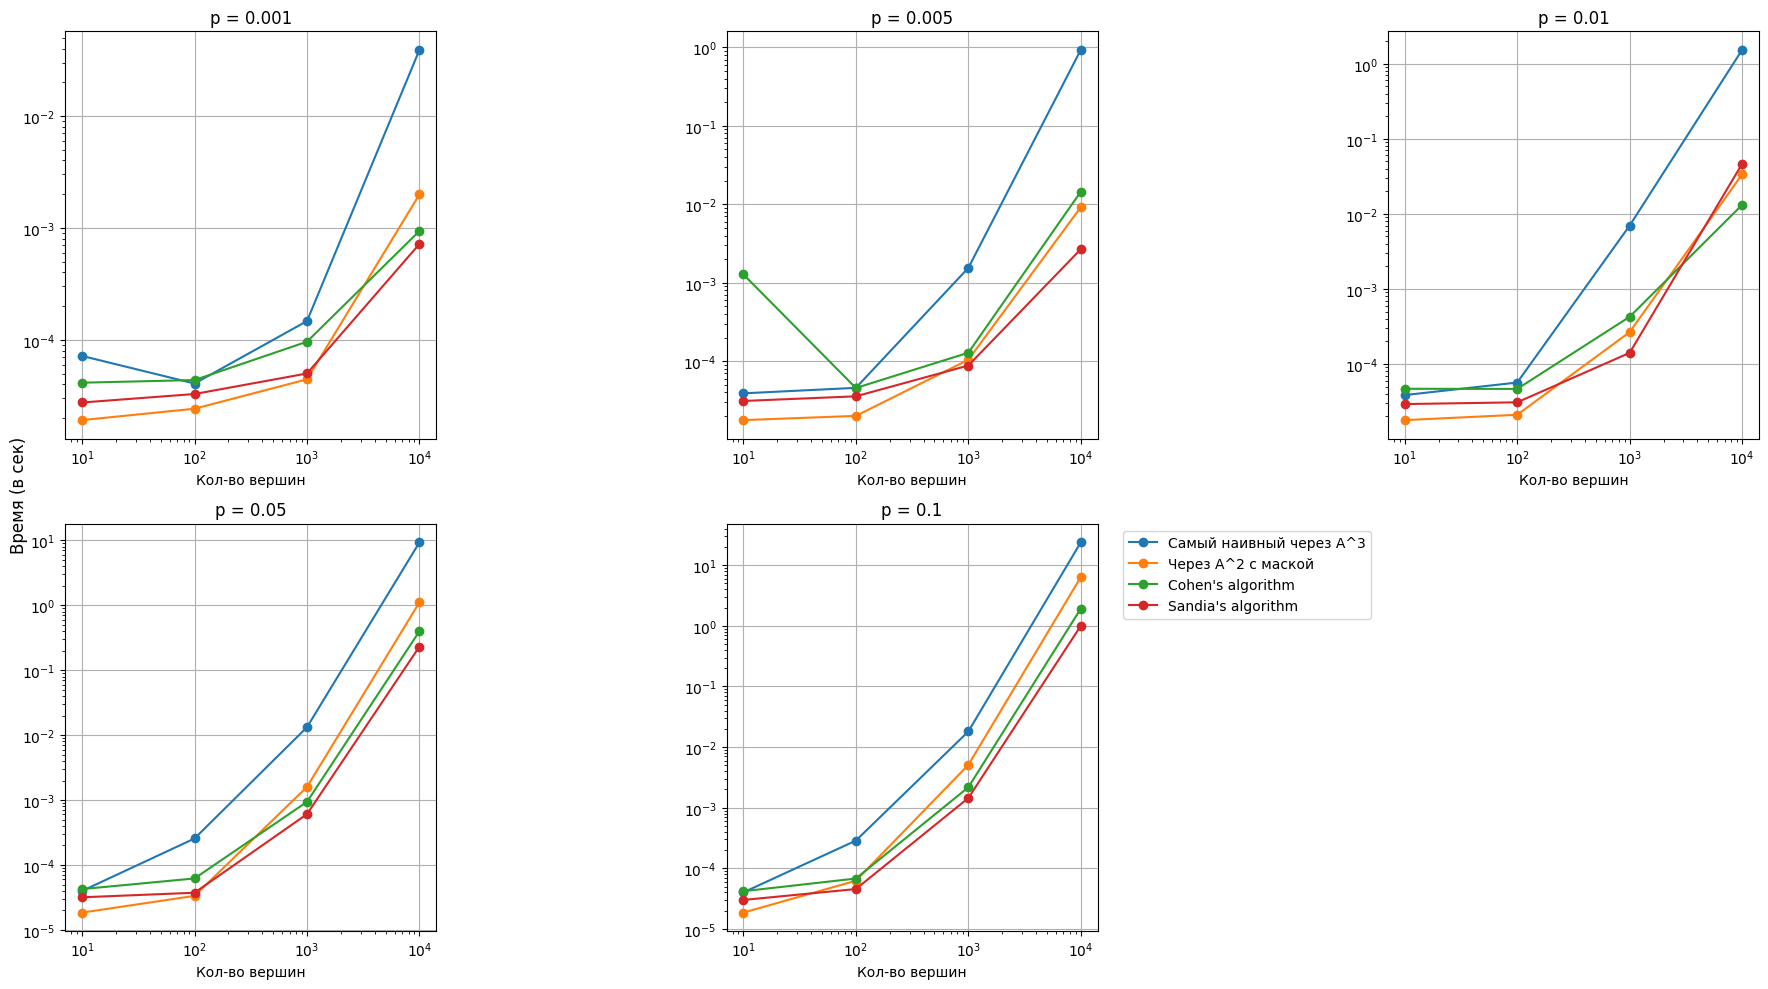

In [21]:
plot_time_vs_param(random_graphs_results_df, group_cols, x_level=0, subplot_level=1, 
                   algos_cols=algos_cols_names, xlabel="Кол-во вершин", title_prefix="p")

**Выводы:**

- Почти для любого уровня разреженности при увеличении кол-ва вершин время работы для всех алгоритмов увеличивается с ростом кол-ва вершин.

- Sandia алгоритм в целом самый быстрый на большом кол-ве вершин (10^3 и 10^4) почти для любого уровня разреженности (кроме p = 0.001: при таком уровне разреженности все алгоритмы кроме самого наивного через куб примерно одинаково быстры)

- Наивный алгоритм всегда самый медленный при кол-ве вершин больше или равно 100. Когда вершин 10 он может быть быстрее Cohen (p = 0.005 и p = 0.01), но в целом также почти самый медленный.

- Алгоритм через A^2 с маской при минимальном кол-ве вершин (10) самый быстрый для любого уровня разреженности. Видимо на маленьких матрицах больше времени тратится на извлечение L и U и их умножение, чем просто умножение изначальной матрицы на себя с маской.

- При очень сильной разреженности (p = 0.001) все алгоритмы кроме наивного работают примерно одинаково быстро (Sandia и алгоритм через A^2 с маской все же чуть побыстрее остальных).

- При малой разреженности (p = 0.1) вперед выходят Cohen и Sandia.

- Наивный алгоритм через A^3 непрактичен, лучше использовать Cohen и Sandia для больших матриц, на очень маленьких можно использовать алгоритм через A^2 с маской.

Теперь посмотрим на график зависимости времени работы алгоритмов от разного уровня разреженности (чем p больше - тем меньше уровень разреженности) (один график на каждое значение n_vertices - кол-во вершин).

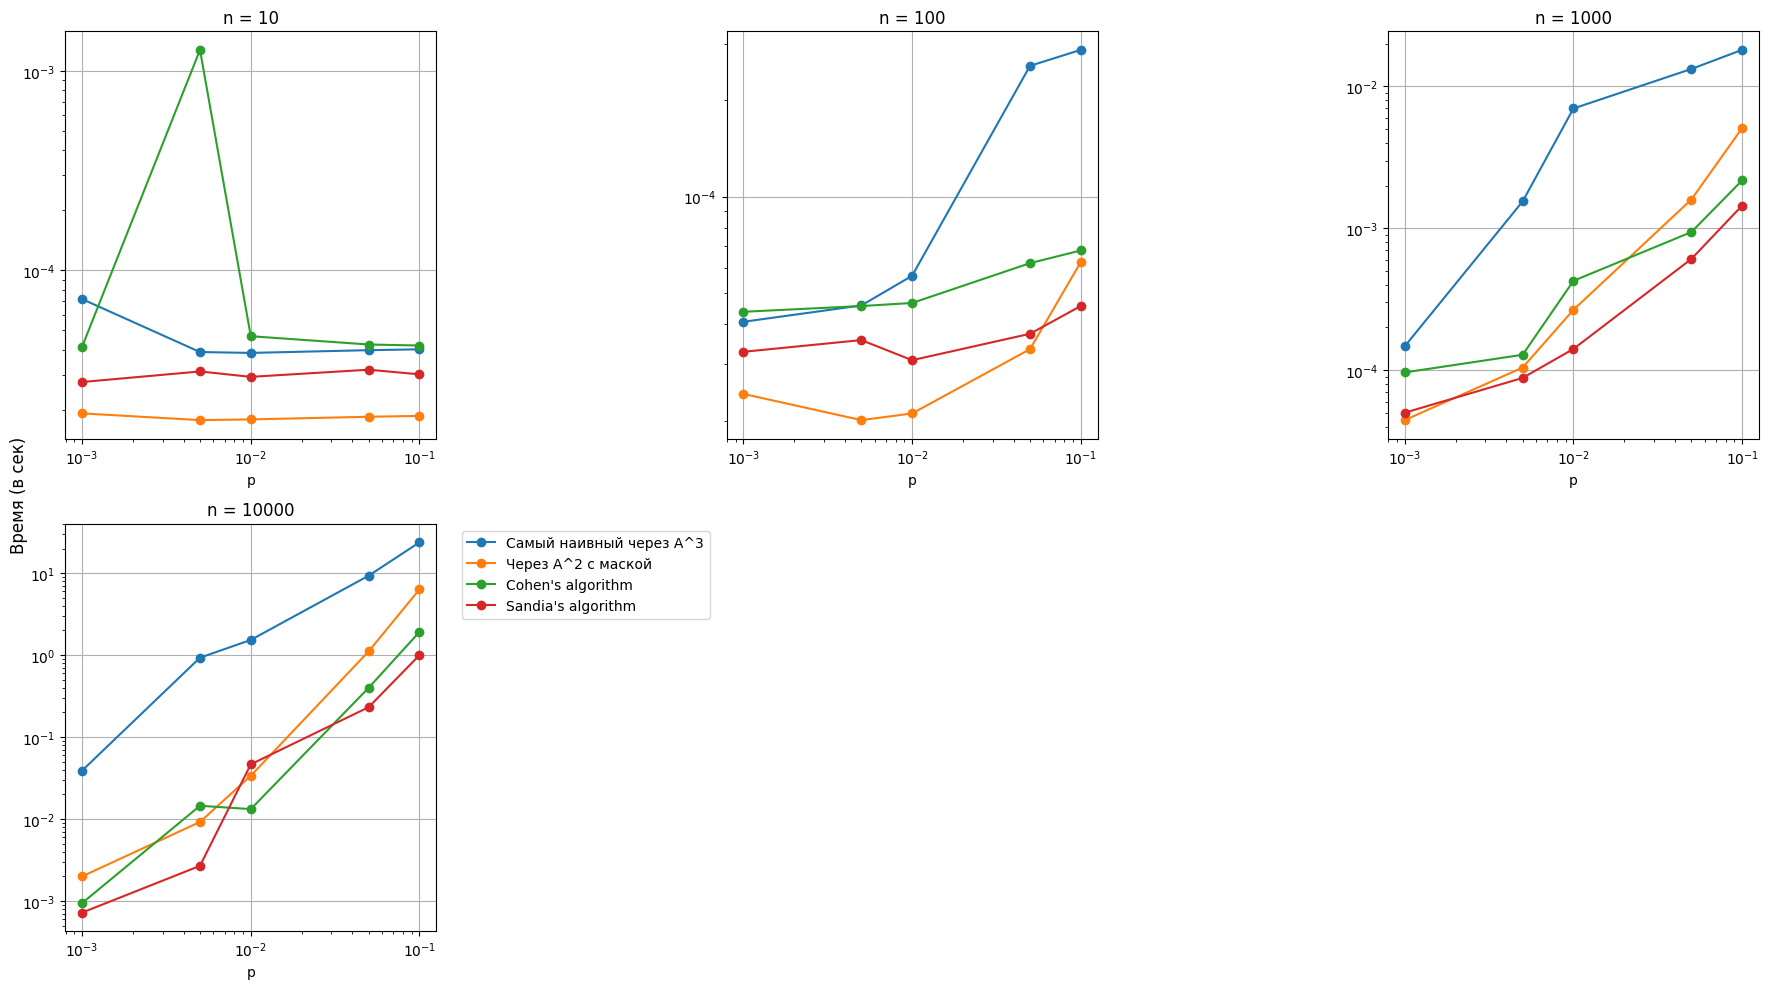

In [22]:
plot_time_vs_param(random_graphs_results_df, group_cols, x_level=1, subplot_level=0,
                   algos_cols=algos_cols_names, xlabel="p", title_prefix="n")

- При очень малом n (10) время почти не зависит от уровня разреженности (выделяется только выброс от Cohen алгоритма).
  
- В целом заметно, что с ростом кол-ва вершин n растет зависимость времени от уровня разреженности - чем менее разрежена матрица (p больше), тем больше времени требуется каждому алгоритму.

- При самом большом p (соответственно при самом малом уровне разреженности) почти на всех графах кроме самого маленького быстрее всех Sandia algorithm, затем - Cohen algorithm.